In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Imports

In [ ]:
%pip install lightgbm

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [ ]:
dataset = "data_set/student_resource/dataset/train.csv"
df = pd.read_csv(dataset)

FileNotFoundError: [Errno 2] No such file or directory: 'data_set/student_resource/dataset/train.csv'

In [ ]:
df.head()

,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [ ]:
# --- Clean text ---
df["catalog_content"] = (
    df["catalog_content"]
    .astype(str)
    .str.replace("Item Name:", "", regex=False)
    .str.strip()
)
df["split_content"] = df["catalog_content"].str.split(",")

In [ ]:
df.head()

,sample_id,catalog_content,image_link,price,split_content,cluster_ids
0,33127,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,"[La Victoria Green Taco Sauce Mild, 12 Ounce ...","[4, 12]"
1,198967,"Salerno Cookies, The Original Butter Cookies, ...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,"[Salerno Cookies, The Original Butter Cookies...","[8, 18, 11, 20]"
2,261251,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,"[Bear Creek Hearty Soup Bowl, Creamy Chicken ...","[8, 18, 4]"
3,55858,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,[Judee’s Blue Cheese Powder 11.25 oz - Gluten-...,"[0, 4, 7, 8, 14, 18, 23]"
4,292686,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,"[kedem Sherry Cooking Wine, 12.7 Ounce - 12 p...","[8, 17]"


# Clustering

In [ ]:
# --- Flatten and deduplicate ---
phrases = [
    p.strip()
    for sub in df["split_content"]
    for p in sub
    if isinstance(p, str) and p.strip() != ""
]
unique_phrases = pd.Series(phrases).drop_duplicates().dropna().tolist()

print(f"Initial unique phrases: {len(unique_phrases)}")

Initial unique phrases: 413910


In [ ]:
df.head()

,sample_id,catalog_content,image_link,price,split_content
0,33127,"La Victoria Green Taco Sauce Mild, 12 Ounce (P...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89,"[La Victoria Green Taco Sauce Mild, 12 Ounce ..."
1,198967,"Salerno Cookies, The Original Butter Cookies, ...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12,"[Salerno Cookies, The Original Butter Cookies..."
2,261251,"Bear Creek Hearty Soup Bowl, Creamy Chicken wi...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97,"[Bear Creek Hearty Soup Bowl, Creamy Chicken ..."
3,55858,Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34,[Judee’s Blue Cheese Powder 11.25 oz - Gluten-...
4,292686,"kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49,"[kedem Sherry Cooking Wine, 12.7 Ounce - 12 p..."


In [ ]:
# --- TF-IDF ---
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=3000,
    ngram_range=(1, 2),
    dtype=np.float32
)

X = vectorizer.fit_transform(unique_phrases)

# Identify which rows survived vectorization (non-empty vectors)
nonzero_indices = np.array(X.sum(axis=1)).ravel() > 0
X = X[nonzero_indices]
filtered_phrases = [phrase for phrase, keep in zip(unique_phrases, nonzero_indices) if keep]

print(f"After filtering, kept {len(filtered_phrases)} phrases (removed empty ones).")

After filtering, kept 400173 phrases (removed empty ones).



Cluster 0: ['or use it as a tasty glaze on your pork or chicken\nBullet Point 5: GMO Free\nProduct Description: Made from the finest ripened black raspberries', "Braswell's Key Lime Marinade for Sole 12oz\nBullet Point: Key Lime Marinade for sole. Very light but with a solid taste!\nProduct Description: Key Lime Marinade for sole. Very light but with a solid taste!\nValue: 12.0\nUnit: Ounce", 'or as a healthy dessert snack.\nBullet Point 8: FUEL YOUR BEST & EXPERIENCE THE KiZE DIFFERENCE!\nBullet Point 9: MADE IN THE USA!\nProduct Description: KiZE Energy Bar 4 Pack\nValue: 4.0\nUnit: Count', 'batch after batch.\nProduct Description: At BulkSupplements.com', 'and Mystery. We ship all of the product from in-house in boxes']

Cluster 1: ['Smooth & Suprisingly Tasty – A cross between tea and coffee', 'Starbucks Ground Coffee', 'Community Coffee Breakfast Blend 36 Count Coffee Pods', 'medium roast coffee with notes of honey and hazelnut.\nBullet Point 2: Coffee Pods: We take high-quality 

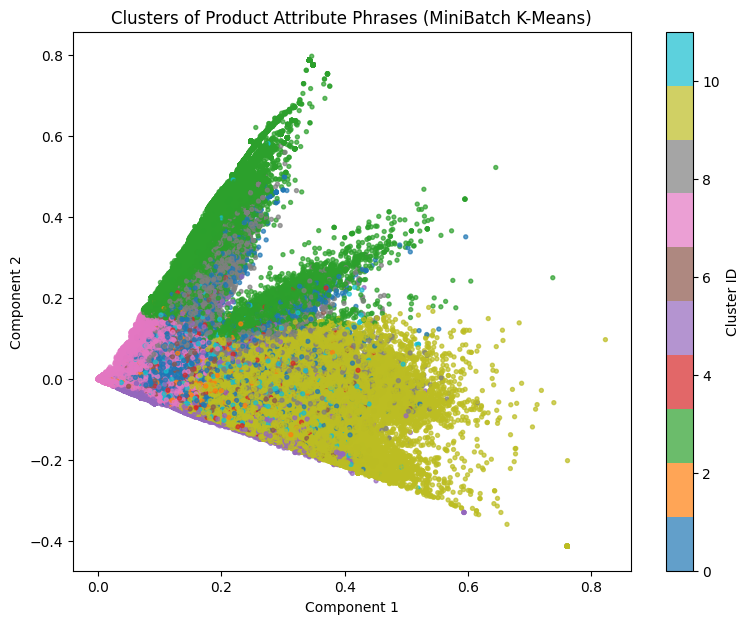

In [ ]:
# --- Dimensionality reduction ---
svd = TruncatedSVD(n_components=100, random_state=42)
X_reduced = svd.fit_transform(X)

# --- MiniBatch KMeans ---
k = 12
kmeans = MiniBatchKMeans(n_clusters=k, batch_size=1000, random_state=42)
labels = kmeans.fit_predict(X_reduced)

# --- Cluster DataFrame ---
cluster_df = pd.DataFrame({"phrase": filtered_phrases, "cluster": labels})

# --- Print a few examples per cluster ---
for c in range(k):
    examples = cluster_df[cluster_df["cluster"] == c]["phrase"].head(5).to_list()
    print(f"\nCluster {c}: {examples}")

# --- 2D Visualization ---
X_vis = X_reduced[:, :2]
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap="tab10", s=8, alpha=0.7)
plt.title("Clusters of Product Attribute Phrases (MiniBatch K-Means)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(scatter, label="Cluster ID")
plt.show()

# Making Features

In [ ]:
# coverting cluster_df to dict for faster lookup
phrase_to_cluster_map = pd.Series(cluster_df.cluster.values, index=cluster_df.phrase).to_dict()

print("Total Phrases", len(phrase_to_cluster_map), "unique phrases")

Total Phrases 400173 unique phrases


In [ ]:
# We'll create a new column 'cluster_ids' that holds a list of cluster!
df['cluster_ids'] = df['catalog_content'].apply(
    lambda content: list(
        set( # 'set' makes sure we only get unique cluster IDs per product!
            phrase_to_cluster_map.get(p.strip())
            for p in content.split(',')
            if p.strip() in phrase_to_cluster_map
        )
    )
)

print(df[['catalog_content', 'cluster_ids']].head())

                                     catalog_content               cluster_ids
0  La Victoria Green Taco Sauce Mild, 12 Ounce (P...                   [4, 12]
1  Salerno Cookies, The Original Butter Cookies, ...           [8, 18, 11, 20]
2  Bear Creek Hearty Soup Bowl, Creamy Chicken wi...                [8, 18, 4]
3  Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...  [0, 4, 7, 8, 14, 18, 23]
4  kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...                   [8, 17]


In [ ]:
mlb = MultiLabelBinarizer()

# Unleash the binarizer on our 'cluster_ids'
cluster_features = mlb.fit_transform(df['cluster_ids'])

# Create a stunning new DataFrame with these features!
cluster_features_df = pd.DataFrame(cluster_features, columns=[f"cluster_{c}" for c in mlb.classes_])

print(cluster_features_df.head())

   cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  cluster_5  \
0          0          0          0          0          1          0   
1          0          0          0          0          0          0   
2          0          0          0          0          1          0   
3          1          0          0          0          1          0   
4          0          0          0          0          0          0   

   cluster_6  cluster_7  cluster_8  cluster_9  ...  cluster_15  cluster_16  \
0          0          0          0          0  ...           0           0   
1          0          0          1          0  ...           0           0   
2          0          0          1          0  ...           0           0   
3          0          1          1          0  ...           0           0   
4          0          0          1          0  ...           0           0   

   cluster_17  cluster_18  cluster_19  cluster_20  cluster_21  cluster_22  \
0           0           0  

In [ ]:
# Let's join the original df with the new cluster features!
final_df = pd.concat([df, cluster_features_df], axis=1)

# We don't need the intermediate 'cluster_ids' list anymore, so let's drop it
final_df = final_df.drop(columns=['cluster_ids'])

print(final_df.head())

   sample_id                                    catalog_content  \
0      33127  La Victoria Green Taco Sauce Mild, 12 Ounce (P...   
1     198967  Salerno Cookies, The Original Butter Cookies, ...   
2     261251  Bear Creek Hearty Soup Bowl, Creamy Chicken wi...   
3      55858  Judee’s Blue Cheese Powder 11.25 oz - Gluten-F...   
4     292686  kedem Sherry Cooking Wine, 12.7 Ounce - 12 per...   

                                          image_link  price  \
0  https://m.media-amazon.com/images/I/51mo8htwTH...   4.89   
1  https://m.media-amazon.com/images/I/71YtriIHAA...  13.12   
2  https://m.media-amazon.com/images/I/51+PFEe-w-...   1.97   
3  https://m.media-amazon.com/images/I/41mu0HAToD...  30.34   
4  https://m.media-amazon.com/images/I/41sA037+Qv...  66.49   

                                       split_content  cluster_0  cluster_1  \
0  [La Victoria Green Taco Sauce Mild,  12 Ounce ...          0          0   
1  [Salerno Cookies,  The Original Butter Cookies...          

In [ ]:
# Select Features (X) and Target (y)
feature_columns = [col for col in final_df.columns if 'cluster_' in col]
X = final_df[feature_columns]
y = final_df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42 # for reproducible results
)
print(f"Training set has {X_train.shape[0]} samples.")
print(f"Testing set has {X_test.shape[0]} samples.")

Training set has 60000 samples.
Testing set has 15000 samples.


In [ ]:
def smape_for_lgbm(y_true, y_pred):
    """
    Custom SMAPE metric for LightGBM's eval_metric.
    """
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    score = np.mean(numerator / (denominator + 1e-8)) * 100

    # The required return format: (metric_name, value, is_higher_better)
    return 'smape', score, False

In [ ]:
models = {
    "LGBM": lgb.LGBMRegressor(
        objective='regression_l1',
        n_estimators=1000,
        learning_rate=0.05,
        random_state=42
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        random_state=42
    ),
    "Ridge": Ridge(alpha=1.0)
}


In [ ]:
# --- Train models and evaluate using SMAPE ---
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == "LGBM":
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric=smape_for_lgbm,
            callbacks=[lgb.early_stopping(100, verbose=True)]
        )
    else:
        model.fit(X_train, y_train)

    preds = model.predict(X_test)
    _, smape_score, _ = smape_for_lgbm(y_test, preds)
    results[name] = smape_score
    print(f"{name} SMAPE: {smape_score:.4f}")

# --- Select best model ---
best_model_name = min(results, key=results.get)
best_model = models[best_model_name]

print(f"\n✅ Best model: {best_model_name} with SMAPE = {results[best_model_name]:.4f}")



Training LGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 50
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 25
[LightGBM] [Info] Start training from score 14.090000
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[427]	valid_0's l1: 15.5213	valid_0's smape: 67.7401
LGBM SMAPE: 67.7401

Training RandomForest...
RandomForest SMAPE: 74.5100

Training GradientBoosting...
GradientBoosting SMAPE: 75.4904

Training Ridge...
Ridge SMAPE: 76.6828

✅ Best model: LGBM with SMAPE = 67.7401


In [ ]:
# --- Train the Model ---
lgbm = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

# Train the model, passing the CORRECTED function
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric=smape_for_lgbm,  # <-- Use the corrected function here
    callbacks=[lgb.early_stopping(100, verbose=True)]
)

print("\nModel training successful! ✅")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 50
[LightGBM] [Info] Number of data points in the train set: 60000, number of used features: 25
[LightGBM] [Info] Start training from score 14.090000
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[427]	valid_0's l1: 15.5213	valid_0's smape: 67.7401

Model training successful! ✅


In [ ]:
# Use the trained model to make predictions
y_pred = lgbm.predict(X_test)

print("Predictions have been made on the test set. ✅")

Predictions have been made on the test set. ✅


In [ ]:
# A simple function for the final calculation
def calculate_smape(y_true, y_pred):
    """Calculates the final SMAPE score and returns a single value."""
    numerator = np.abs(y_pred - y_true)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    score = np.mean(numerator / (denominator + 1e-8)) * 100
    return score

# Calculate and print the final score
final_score = calculate_smape(y_test, y_pred)

print(f"Final SMAPE Score on the Test Set: {final_score:.2f}%")

Final SMAPE Score on the Test Set: 67.74%


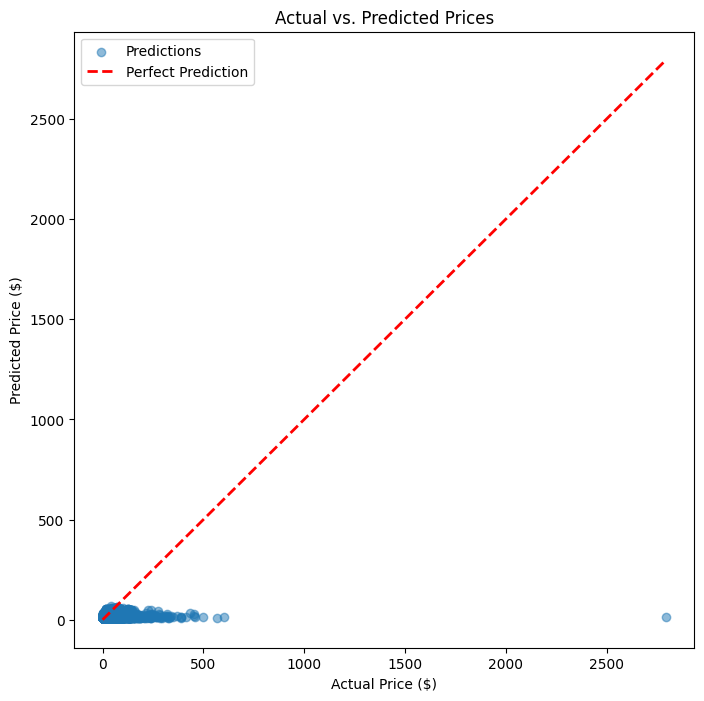

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predictions')

# Add the perfect prediction line (y=x)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--', color='red', lw=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.show()